# Hands-On AI for Science
### Aug 13 Afternoon: Lexical Embedding (word2vec)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhasegaw/hands_on_ai_for_science/blob/main/lectures/colab/a13pm_word2vec_colab.ipynb)

**No Python installed?** Click the badge above to open a self-contained version of this notebook in Google Colab.  It runs in your browser, with nothing to download and nothing to install.

All modern AI systems use real-valued vectors to represent words (or parts of words), in order to perform computations like next-word prediction, speech recognition, and natural language generation.  The vector representation of a word is typically called its [lexical embedding](https://en.wikipedia.org/wiki/Word_embedding).  A lexical embedding is just a dictionary: for every word known to the language model, there is a corresponding vector.  Typically, each vector is 300 or 500 dimensions, but we usually imagine them as if they were 2-dimensional vectors.  Typically, we want the 500 dimensions of the vectors space to be **structured**, so that, for example, if $\mathbf{x}$ is the name of a country, and $\mathbf{y}$ is the name of its capital, then the vector $\mathbf{y}-\mathbf{x}$ is the same, regardless of which country we're talking about:

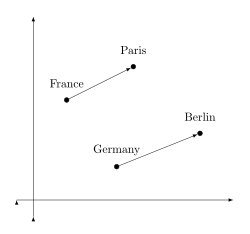

Similarly, if $\mathbf{x}$ is the name of a male role in society (such as "king"), and $\mathbf{y}$ is the name of the corresponding female role (such as "queen"), we hope that the difference $\mathbf{y}-\mathbf{x}$ will be the same, regardless of which role in society we're talking about:

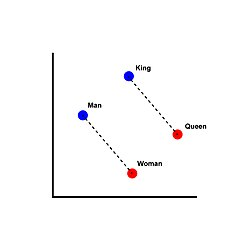

But how can we create embeddings like that?

The answer is that embeddings must somehow be learned from data.  Usually this involves three steps:

1. Initialize: Create some initial vector (maybe random) for every word
2. Measure the Loss: Measure how bad the initial vectors are
3. Improve: Use some type of <a href="https://en.wikipedia.org/wiki/Hill_climbing">hill-climbing method</a> to improve all of the vectors

One example of an effective, computationally efficient method for learning lexical embeddings is the skipgram noise contrastive estimation method proposed by [Mikolov, Sutskever, Chen, Corrado and Dean](https://proceedings.neurips.cc/paper/2013/hash/9aa42b31882ec039965f3c4923ce901b-Abstract.html) in 2014, and released as part of their patented [word2vec](https://code.google.com/archive/p/word2vec/) codebase. In this notebook, you will implement a method to train lexical embeddings based on the algorithm described in their paper, with some modifications to make it easier to implement in a jupyter notebook.  We will abbreviate the algorithm name as word2vec, as did the authors.

As you work your way through this notebook, it will suggest ways in which you can modify the methods in the attached file `a13am_hw1.py`.  Each time you modify that file, you'll need to reload the contents into this file.  One way to do so is using the code below:



In [1]:
import importlib, a13pm_hw1
importlib.reload(a13pm_hw1)

<module 'a13pm_hw1' from '/Users/jhasegaw/Dropbox/mark/teaching/minicourse/2026/aug/hands_on_ai_for_science/lectures/a13pm_hw1.py'>

### Table of Contents

1. <a href="#1-initialize-the-embeddings">Initialize the Embeddings</a>
1. <a href="#2-gradients-of-the-skipgram-nce-loss">Measure the Loss: Skipgram noise contrastive embedding</a>
1. <a href="#3-stochastic-gradient-descent">Hill climbing: Stochastic Gradient Descent</a>


## 1. Initialize the Embeddings

In order to improve your embeddings, you have to have some embeddings to improve.  Word2vec can only get started if you first decide what words you want in your dictionary, then create some initial embedding for each of those words.  Most machine learning algorithms use random initialization, but in order to help with debugging, we will use a special type of initialization, described in the docstring:


In [2]:
help(a13pm_hw1.initialize)

Help on function initialize in module a13pm_hw1:

initialize(data, dim)
    Initialize embeddings for all distinct words in the input data.
    Most of the dimensions will be zero-mean unit-variance Gaussian random variables.
    In order to make debugging easier, however, we will assign special geometric values
    to the first two dimensions of the embedding:

    (1) Find out how many distinct words there are.
    (2) Choose that many locations uniformly spaced on a unit circle in the first two dimensions.
    (3) Put the words into those spots in the same order that they occur in the data.

    Thus if data[0] and data[1] are different words, you should have

    embedding[data[0]] = np.array([np.cos(0), np.sin(0), random, random, random, ...])
    embedding[data[1]] = np.array([np.cos(2*np.pi/N), np.sin(2*np.pi/N), random, random, random, ...])

    ... and so on, where N is the number of distinct words, and each random element is
    a Gaussian random variable with mean=0 and sta

We need some data.  For now, let's use the following dummy data.  We can start out with 4-dimensional embeddings.  That's smaller than we would normally use, but it will avoid wasting computation while we debug.

In [3]:
data='''
# # #
apple bear cat dog apple bear cat dog apple bear cat dog apple bear cat dog
# # #
egg fox goat heron egg fox goat heron egg fox goat heron egg fox goat heron
# # #
'''.split()
print("The data are",data)

The data are ['#', '#', '#', 'apple', 'bear', 'cat', 'dog', 'apple', 'bear', 'cat', 'dog', 'apple', 'bear', 'cat', 'dog', 'apple', 'bear', 'cat', 'dog', '#', '#', '#', 'egg', 'fox', 'goat', 'heron', 'egg', 'fox', 'goat', 'heron', 'egg', 'fox', 'goat', 'heron', 'egg', 'fox', 'goat', 'heron', '#', '#', '#']


In [4]:
importlib.reload(a13pm_hw1)
embeddings = a13pm_hw1.initialize(data, 4)
print('The embedding for "#" is',embeddings['#'])
print('The embedding for "apple" is',embeddings['apple'])
print('The embedding for "bear" is',embeddings['bear'])

The embedding for "#" is [ 1.          0.         -0.12994034  0.70544012]
The embedding for "apple" is [0.76604444 0.64278761 0.00613713 0.96525699]
The embedding for "bear" is [ 0.17364818  0.98480775 -2.05808734 -0.80806966]


The first two dimensions of each embedding are the same.  The next two dimensions should be uniformly spaced around a circle. 

Let's use `text` to put the first letter of each word at the corresponding spot on the circle.  The order of your words might be different from mine, depending on how you sorted the words; that shouldn't matter, as long as you have one vector for each word.

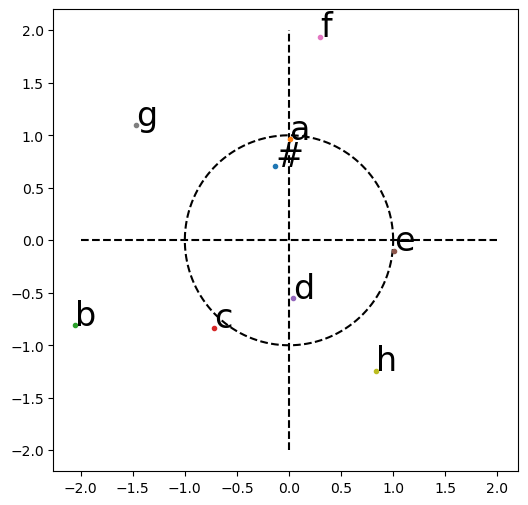

In [5]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(figsize=(6,6))
ax0 = fig.add_subplot(1,1,1)

# Plot the axes as dashed lines
theta = np.linspace(0,2*np.pi,1000)
ax0.plot([-2,2],[0,0],'k--',[0,0],[-2,2],'k--',np.cos(theta),np.sin(theta),'k--')

# Plot the vector value of each embedding
for w,v in embeddings.items():
    ax0.plot(v[2],v[3], '.')
    ax0.text(v[2],v[3],w[0],None,fontsize=24)


If you've done this correctly, you should now have nine embeddings (one for each distinct word), and they should be uniformly spaced around a unit circle in the third and fourth dimensions, starting at $\theta=0$, and ending at $\theta=\frac{16\pi}{9}$.  Note, as mentioned before, this initialization is not really necessary for good performance of the algorithm; we're just doing it to help with debugging.

## 2. Word2vec loss: Skipgram Noise Contrastive Embedding

Word2vec was trained using J.R. Firth's definition of lexical semantics: <a href="https://en.wikipedia.org/wiki/John_Rupert_Firth#Contributions_to_linguistics">"You shall know a word by the company it keeps."</a>  Turned into an algorithm, Firthian semantics translates to the following idea:

* If two words often occur near one another in the training data, then their lexical embeddings should be similar.
* If they rarely occur near one another in the training data, then their lexical embeddings should be different.

These criteria are enforced by starting with a random or pseudo-random embedding, then doing a series of hill-climbing updates.  Each hill-climbing update moves each word's embedding a short distance in a direction determined as follows:

* Move closer to the embeddings of all words that occur next to me in the training data.  Pairs of words that occur next to each other in the training data are called "skip-grams" -- "skip" means that they might occur right next to each other, or separated by one or two words in between.  For this jupyter notebook, let's use the first three skipgrams in either direction: We want the embedding of word $\mathbf{w}_t$ to be close to the embeddings of words $\mathbf{w}_{t-3}$, $\mathbf{w}_{t-2}$, $\mathbf{w}_{t-1}$, $\mathbf{w}_{t+1}$, $\mathbf{w}_{t+2}$, and $\mathbf{w}_{t+3}$.
* Move away from the embeddings of all other words.  This is called "noise contrastive embedding" -- it means we select, at random, some set of other words (the "noise"), and move away from them (the "contrast").  For a small vocabulary like ours, rather than stop to figure out which words are "noise", we can do pretty well by just using every word in the vocabulary -- so we will move away from all of the nine vectors representing all nine of the words:

<p style="text-align: center;">
$\mathcal{V}=\{$#,apple,bear,cat,dog,egg,fox,goat,heron$\}$
</p>


### Loss gradient: The direction that makes performance worse

Neural networks are trained using the equation $\mathbf{w}=\mathbf{w}-\eta\mathbf{g}_t$, where $\mathbf{g}_t$ is the direction that makes performance **worse**, and $\eta$ is some small constant update step size, usually $\eta\approx 0.01$.  If there is some measure of how badly the neural network will perform, $\mathbf{g}_t$ is the derivative of that measure with respect to the weights.

Which direction makes $\mathbf{w}_t$ **less** like its similar words?  That would be the direction that moves toward the average of all words, but away from the average of its nearby words.  In other words:

$$\mathbf{g}_t = \frac{1}{9} \sum_{\mathbf{v}\in\mathcal{V}} \mathbf{v} - \frac{1}{6}\sum_{c=-3}^3 \mathbf{w}_{t+c}$$

Word2vec proposed one more modification.  Instead of counting every neighboring word equally, 
* word2vec moves most rapidly toward words that are not yet very similar.  When it becomes very similar to those words, it can stop changing.
* word2vec moves most rapidly away from words that are already too similar.  When it becomes very dissimilar to those words, it can stop changing.

Similarity is measured using an idea from psychometrics called the <a href="https://en.wikipedia.org/wiki/Logistic_function">logistic sigmoid function</a>:

$$s(\mathbf{w},\mathbf{v}) = \frac{1}{1+e^{-\mathbf{w}^T\mathbf{v}}}$$

where $\mathbf{w}^T\mathbf{v}$ is the dot product between vectors $\mathbf{w}$ and $\mathbf{v}$, thus in numpy this is implemented in numpy as:

```
s = 1/(1+np.exp(-np.dot(w,v)))
```

Speeding up the movement toward dissimilar words, and speeding up the movement away from similar words, is done using $\mathbf{w}_t=\mathbf{w}_t-\eta\mathbf{g}_t$, where:

$$\mathbf{g}_t = \frac{1}{9} \sum_{\mathbf{v}\in\mathcal{V}} s(\mathbf{w}_t,\mathbf{v})\mathbf{v} - \frac{1}{6}\sum_{c=-3}^3 \left(1-s(\mathbf{w}_t,\mathbf{w}_{t+c})\right)\mathbf{w}_{t+c}$$



In the file `a13pm_hw1.py`, the update direction is called `gradient`:

In [6]:
importlib.reload(a13pm_hw1)
help(a13pm_hw1.gradient)

Help on function gradient in module a13pm_hw1:

gradient(embedding, data, t, d=2, k=10)
    Calculate gradient of the skipgram NCE loss with respect to the embedding of data[t]

    @param:
    embedding - dict mapping from words (strings) to numpy arrays.
    data (list) - list of words in the input text, split on whitespace
    t (int) - data index of word with respect to which you want the gradient
    d (int) - choose context words from t-d through t+d, not including t
    k (int) - compare each context word to k words chosen uniformly at random from the data

    @return:
    g (numpy array) - loss gradients with respect to embedding of data[t]



Try revising the function `negativegradient`, and then calculate the negative gradients for a few of the different words in the training data.  Notice that the negative gradient for different tokens of any given word might be different, depending on the context:

In [7]:
importlib.reload(a13pm_hw1)

directions = []
for t in range(10):
    d = a13pm_hw1.gradient(embeddings, data, t)
    directions.append(d)
    print('Update direction for',data[t],'is',d)


Update direction for # is [ 0.18595668 -0.06248556 -0.64739209  0.31026107]
Update direction for # is [ 0.2243441  -0.12965544  0.1171168   0.54240715]
Update direction for # is [ 0.49964604 -0.96316227  0.41902145  1.29705204]
Update direction for apple is [ 0.51044874 -0.8548936   1.10082141  1.33128893]
Update direction for bear is [ 0.04765163 -0.13798934 -1.02776425 -0.04757472]
Update direction for cat is [-0.96096765 -0.4058665  -0.88568178 -1.52916905]
Update direction for dog is [-1.06500924 -1.02417488  1.29786739 -0.24714542]
Update direction for apple is [ 1.96311834 -1.84966592  1.6611265   2.72676412]
Update direction for bear is [ 0.90864022 -0.43399962 -0.63018177  0.20680624]
Update direction for cat is [-1.04390379 -0.51175329 -0.76854483 -1.68915921]


If we plot the negative gradients, you should find that all of the first ten words move in the direction of the average of words "apple" through "dog", and away from the average of words "egg" through "heron".

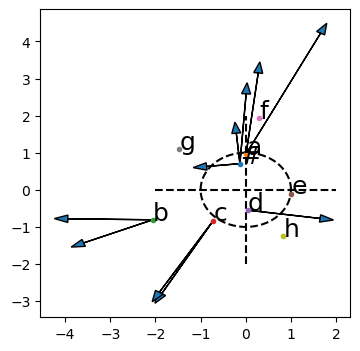

In [8]:
fig = plt.figure(figsize=(4,4))
ax0 = fig.add_subplot(1,1,1)

# Plot the axes as dashed lines
theta = np.linspace(0,2*np.pi,1000)
ax0.plot([-2,2],[0,0],'k--',[0,0],[-2,2],'k--',np.cos(theta),np.sin(theta),'k--')

# Plot the vector value of each embedding
for w,v in embeddings.items():
    ax0.plot(v[2],v[3], '.')
    ax0.text(v[2],v[3],w[0],None,fontsize=18)
    
# Plot the negative gradients as arrows pointing away from their current embeddings
lr = 0.5
for t in range(10):
    d = a13pm_hw1.gradient(embeddings, data, t)
    v = embeddings[data[t]]
    ax0.arrow(v[2],v[3],d[2],d[3],head_width=0.2)


## 3. Stochastic Gradient Descent

Stochastic gradient descent repeats the following steps:

1. Choose a word uniformly at random from the data, maybe using the function <a href="https://docs.python.org/3/library/random.html">random.randrange</a>
2. Compute its negative gradient.
3. Move the embedding of that word in the direction of the negative gradient, scaled by the learning rate.

Using the functions defined earlier, your final task is to implement these steps in a function called `sgd`:

In [9]:
importlib.reload(a13pm_hw1)
help(a13pm_hw1.sgd)

Help on function sgd in module a13pm_hw1:

sgd(embedding, data, learning_rate, num_iters, d=2, k=10)
    Perform num_iters steps of stochastic gradient descent.

    @param:
    embedding - dict mapping from words (strings) to numpy arrays.
    data (list) - list of words in the input text, split on whitespace
    learning_rate (scalar) - scale the negative gradient by this amount at each step
    num_iters (int) - the number of iterations to perform
    d (int) - context width hyperparameter for gradient computation
    k (int) - noise sample size hyperparameter for gradient computation

    @return:
    embedding - the updated embeddings



After running a few thousand iterations of SGD, you should find that the set {'a','b','c','d'} have all clustered together, as has the set {'e','f','g','h'}.  The '#' symbol occurs equally often in either context, so it shows up in the middle of the vector space:

In [10]:
importlib.reload(a13pm_hw1)
embeddings = a13pm_hw1.sgd(embeddings, data, 0.01, 2000)

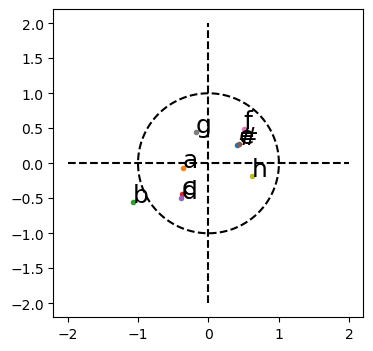

In [11]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(figsize=(4,4))
ax0 = fig.add_subplot(1,1,1)

# Plot the axes as dashed lines
theta = np.linspace(0,2*np.pi,1000)
ax0.plot([-2,2],[0,0],'k--',[0,0],[-2,2],'k--',np.cos(theta),np.sin(theta),'k--')

# Plot the vector value of each embedding
for w,v in embeddings.items():
    ax0.plot(v[2],v[3], '.')
    ax0.text(v[2],v[3],w[0],None,fontsize=18)


You might find it interesting to test your code with real data, and/or to experiment with one of the lexical embedding demos online, e.g., https://remykarem.github.io/word2vec-demo/.